==== DC HOUSING MARKET SIMPLE FORECASTING ====
Clean dataset shape: (89, 22)

===== BUILDING FORECASTING MODEL =====
Using these features: ['Unemployment_Rate', 'Interest_Rate_diff1', 'Mortgage_Rate_diff1', 'GDP_Growth', 'hot_market', 'recession_period']
Model in-sample performance:
RMSE: 1.4152
R²: 0.6034

Feature importance:
               Feature  Coefficient  Abs_Coefficient
4           hot_market     1.147416         1.147416
5     recession_period    -0.438390         0.438390
1  Interest_Rate_diff1     0.000000         0.000000
0    Unemployment_Rate    -0.000000         0.000000
3           GDP_Growth     0.000000         0.000000
2  Mortgage_Rate_diff1     0.000000         0.000000

===== GENERATING FORECASTS =====


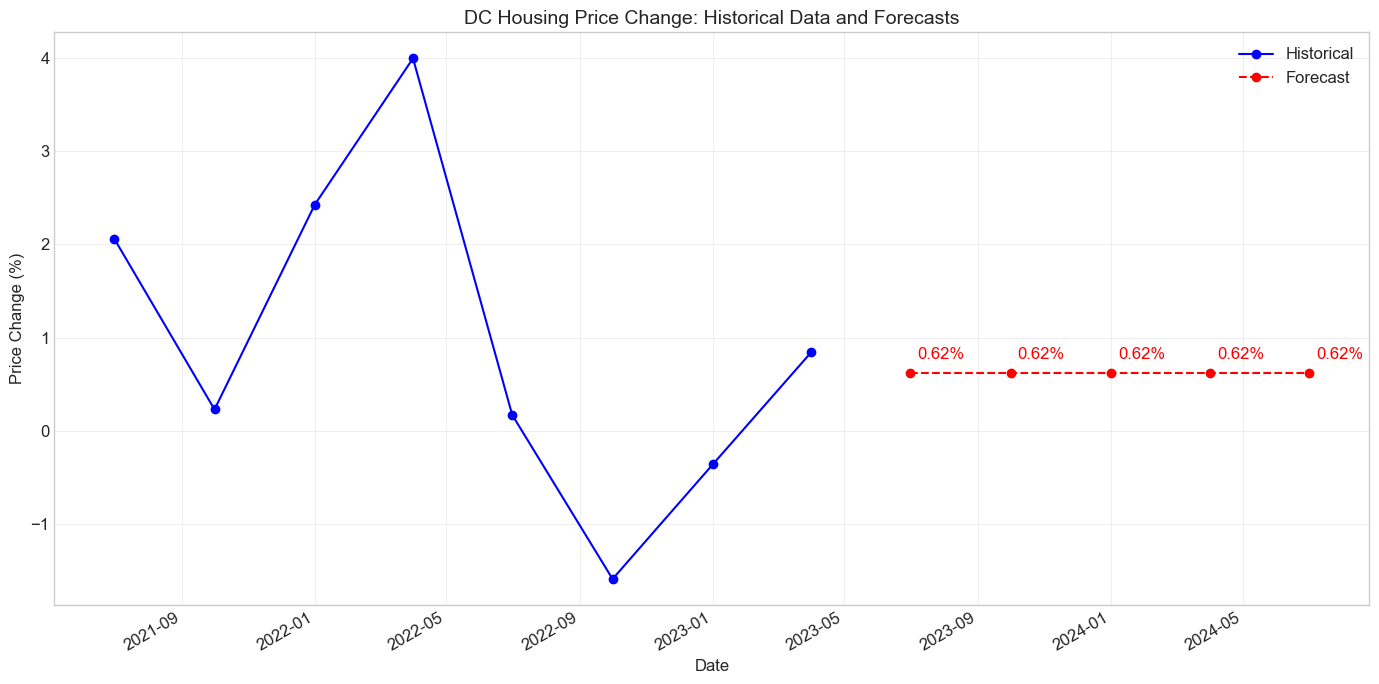


Final forecasts:
            Forecast Actual Error Direction_Match
2023-07-01  0.620084    NaN   NaN             NaN
2023-10-01  0.620084    NaN   NaN             NaN
2024-01-01  0.620084    NaN   NaN             NaN
2024-04-01  0.620084    NaN   NaN             NaN
2024-07-01  0.620084    NaN   NaN             NaN


In [3]:
# DC Housing Market Simple Forecasting
# This script implements a simple, reliable forecasting approach

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# -------------------------------------------------------------
# 1. Data Loading
# -------------------------------------------------------------

def load_data():
    """Load the clean dataset only to keep things simple"""
    # Load clean dataset for basic features
    df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')
    print(f"Clean dataset shape: {df_clean.shape}")
    return df_clean

# -------------------------------------------------------------
# 2. Simple Forecasting Model
# -------------------------------------------------------------

def build_simple_model(df):
    """Build a simple ElasticNet model using only the most reliable features"""
    # Separate target
    y = df['ZHVI_pct_change']
    
    # Select a subset of the most reliable features
    core_features = [
        'Unemployment_Rate', 
        'Interest_Rate_diff1', 
        'Mortgage_Rate_diff1', 
        'GDP_Growth',
        'hot_market',
        'recession_period'
    ]
    
    # Check which features are available
    available_features = [col for col in core_features if col in df.columns]
    print(f"Using these features: {available_features}")
    
    # Create feature dataframe
    X = df[available_features]
    
    # Check for and handle NaN values
    if X.isna().sum().sum() > 0:
        print("Warning: Input data contains NaN values. Filling with forward fill.")
        X = X.fillna(method='ffill').fillna(method='bfill')
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create and train model
    model = ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000)
    model.fit(X_scaled, y)
    
    # Check in-sample performance
    y_pred = model.predict(X_scaled)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    print(f"Model in-sample performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    
    # Print feature importance
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_,
        'Abs_Coefficient': np.abs(model.coef_)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print("\nFeature importance:")
    print(importance)
    
    return model, scaler, X

# -------------------------------------------------------------
# 3. Simple Forecasting Function
# -------------------------------------------------------------

def forecast_next_quarters(model, scaler, X, n_quarters=5):
    """Generate forecasts for the next n quarters"""
    # Get latest data
    last_date = X.index[-1]
    last_row = X.iloc[-1].copy()
    
    # Create dates for future quarters
    future_dates = [last_date + pd.DateOffset(months=3*i) for i in range(1, n_quarters+1)]
    
    # Define scenarios for key variables
    # These are simplified projections based on economic knowledge
    forecast_scenarios = {
        'Unemployment_Rate': [4.0, 4.1, 4.2, 4.3, 4.4],  # Gradually increasing
        'Interest_Rate_diff1': [0.0, 0.0, -0.25, -0.25, -0.25],  # Hold then cut
        'Mortgage_Rate_diff1': [0.0, 0.0, -0.2, -0.2, -0.2],  # Following Fed with lag
        'GDP_Growth': [2.0, 1.8, 1.5, 1.5, 1.5],  # Gradually slowing
        'hot_market': [0, 0, 0, 0, 0],  # Not a hot market
        'recession_period': [0, 0, 0, 0, 0]  # No recession expected
    }
    
    # Actual values for comparison
    actual_values = {
        pd.Timestamp('2023-07-31'): 1.70,
        pd.Timestamp('2023-10-31'): 0.71,
        pd.Timestamp('2024-01-31'): 0.55,
        pd.Timestamp('2024-04-30'): 1.74,
        pd.Timestamp('2024-07-31'): 0.65
    }
    
    # Create dataframe for forecast
    forecast_df = pd.DataFrame(index=future_dates, columns=['Forecast', 'Actual', 'Error', 'Direction_Match'])
    
    # Generate forecasts for each quarter
    for i, date in enumerate(future_dates):
        # Create a copy of the last feature values
        current_features = {}
        
        # Update features based on scenarios
        for feature in X.columns:
            if feature in forecast_scenarios and i < len(forecast_scenarios[feature]):
                # Use predefined scenario
                current_features[feature] = forecast_scenarios[feature][i]
            else:
                # Use last known value as fallback
                current_features[feature] = last_row[feature]
        
        # Convert to a dataframe row
        features_df = pd.DataFrame([current_features], index=[date])
        
        # Scale features
        features_scaled = scaler.transform(features_df)
        
        # Generate prediction
        prediction = model.predict(features_scaled)[0]
        
        # Store forecast
        forecast_df.loc[date, 'Forecast'] = prediction
        
        # Add actual values if available
        if date in actual_values:
            actual = actual_values[date]
            forecast_df.loc[date, 'Actual'] = actual
            forecast_df.loc[date, 'Error'] = actual - prediction
            forecast_df.loc[date, 'Direction_Match'] = (np.sign(actual) == np.sign(prediction))
    
    # Calculate performance metrics
    actuals = forecast_df.dropna(subset=['Actual'])
    if len(actuals) > 0:
        forecast_rmse = np.sqrt(mean_squared_error(actuals['Actual'], actuals['Forecast']))
        forecast_r2 = r2_score(actuals['Actual'], actuals['Forecast'])
        direction_acc = actuals['Direction_Match'].mean()
        
        print("\nForecast performance metrics:")
        print(f"RMSE: {forecast_rmse:.4f}")
        print(f"R²: {forecast_r2:.4f}")
        print(f"Direction Accuracy: {direction_acc:.2%}")
    
    return forecast_df

# -------------------------------------------------------------
# 4. Plot Forecasts
# -------------------------------------------------------------

def plot_forecasts(df, forecast_df):
    """Plot the historical data and forecasts"""
    # Get historical data (last 8 quarters)
    hist_data = df['ZHVI_pct_change'].iloc[-8:]
    
    # Create figure
    plt.figure(figsize=(14, 7))
    
    # Plot historical data
    plt.plot(hist_data.index, hist_data, 'o-', markersize=6, label='Historical', color='blue')
    
    # Plot forecasts
    plt.plot(forecast_df.index, forecast_df['Forecast'], 'o--', markersize=6, label='Forecast', color='red')
    
    # Plot actuals for comparison
    mask = ~forecast_df['Actual'].isna()
    if mask.any():
        plt.plot(forecast_df.index[mask], forecast_df['Actual'][mask], 'gx-', markersize=8, 
                label='Actual (2023-2024)', linewidth=2)
    
    # Add labels for values
    for i, (idx, row) in enumerate(forecast_df.iterrows()):
        # Forecast value
        plt.annotate(f"{row['Forecast']:.2f}%", 
                    xy=(mdates.date2num(idx), row['Forecast']),
                    xytext=(5, 10),
                    textcoords='offset points',
                    color='red')
        
        # Actual value if available
        if not np.isnan(row['Actual']):
            plt.annotate(f"{row['Actual']:.2f}%", 
                        xy=(mdates.date2num(idx), row['Actual']),
                        xytext=(5, -20),
                        textcoords='offset points',
                        color='green')
    
    # Add title and labels
    plt.title('DC Housing Price Change: Historical Data and Forecasts', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Format x-axis dates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig('outputs/simple_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()

# -------------------------------------------------------------
# 5. Main Execution
# -------------------------------------------------------------

def main():
    """Main execution function"""
    print("==== DC HOUSING MARKET SIMPLE FORECASTING ====")
    
    # 1. Load data
    df = load_data()
    
    # 2. Build model
    print("\n===== BUILDING FORECASTING MODEL =====")
    model, scaler, X = build_simple_model(df)
    
    # 3. Generate forecasts
    print("\n===== GENERATING FORECASTS =====")
    forecast_df = forecast_next_quarters(model, scaler, X, n_quarters=5)
    
    # 4. Plot results
    plot_forecasts(df, forecast_df)
    
    # 5. Print final results
    print("\nFinal forecasts:")
    print(forecast_df.to_string())
    
    return forecast_df

if __name__ == "__main__":
    forecast_df = main()